# Exercises: Data Preparation Case Studies

The goal of the exercises below is for you to practice applying preprocessing steps correctly in a model evaluation workflow, using `Pipeline` and `Cross-Validation` to avoid data leakage.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from numpy import mean, std, absolute
from matplotlib import pyplot

# Enable experimental features
from sklearn.experimental import enable_iterative_imputer  # Needed for IterativeImputer

# Sklearn Preprocessing
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    PowerTransformer, QuantileTransformer, KBinsDiscretizer,
    PolynomialFeatures, OneHotEncoder, LabelEncoder
)
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# Sklearn Feature Selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_regression, RFE

# Sklearn Modeling
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, HuberRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

# Sklearn Model Selection and Metrics
from sklearn.model_selection import (
    cross_val_score, RepeatedStratifiedKFold, RepeatedKFold,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, mean_absolute_error

# Sklearn Datasets
from sklearn.datasets import make_classification, make_regression, fetch_openml, fetch_california_housing

## --- Helper Functions ---

In [2]:
def load_horse_colic():
    """Load the Horse Colic dataset from URL and handle missing values."""
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/horse-colic.csv'
    df = pd.read_csv(url, header=None, na_values='?')
    # Column 23 is the outcome (surgical or not), no missing values
    # Other columns are inputs
    data = df.values
    ix = [i for i in range(data.shape[1]) if i != 23]
    X, y = data[:, ix], data[:, 23]
    # Ensure y is integer
    y = y.astype(int)
    return X, y

def load_sonar():
    """Load the Sonar dataset from URL."""
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv'
    df = pd.read_csv(url, header=None)
    data = df.values
    X, y = data[:, :-1], data[:, -1]
    X = X.astype('float32')
    y = LabelEncoder().fit_transform(y.astype('str'))
    return X, y

def load_abalone():
    """Load the Abalone dataset from URL."""
    url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/abalone.csv'
    df = pd.read_csv(url, header=None)
    # Last column is the target (rings)
    last_ix = len(df.columns) - 1
    X, y = df.drop(last_ix, axis=1), df[last_ix]
    return X, y

### Dataset Introduction: Pima Indians Diabetes

This is a classic classification dataset, loaded directly from a URL. The goal is to predict whether a person has diabetes ('class' column) based on 8 medical features. 

An important characteristic of this dataset is that it contains invalid zero values (e.g., blood pressure = 0 in columns like 'pres', 'plas'...), which require Data Cleaning before processing.

## --- Problem 1: Compare the effectiveness of Scaling with KNN ---

In [4]:
print("\n--- Problem 1: Pima Diabetes Data (Scaling) ---")
# 1. Load the Pima Indians Diabetes dataset from URL
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
names = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class']
df_pima = pd.read_csv(url, header=None, names=names)

# 2. Replace invalid zero values with NaN in specific columns
cols_with_zero_nan = ['plas', 'pres', 'skin', 'insu', 'mass']
df_pima[cols_with_zero_nan] = df_pima[cols_with_zero_nan].replace(0, np.nan)

# Split X and y (y is already 0 or 1, no LabelEncoder needed)
X_pima = df_pima.drop('class', axis=1).values
y_pima = df_pima['class'].values
print("Pima Indians Diabetes dataset loaded successfully from URL.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Create 3 separate Pipelines (MinMaxScaler, StandardScaler, RobustScaler).
# 2. Each Pipeline must include 3 steps: ('i', SimpleImputer(strategy='mean')), ('s', [Corresponding Scaler]), ('m', KNeighborsClassifier()).
# 3. Define RepeatedStratifiedKFold (10 splits, 3 repeats, random_state=1).
# 4. Evaluate and print the mean accuracy for all 3 pipelines.
# 5. (Optional) Plot a boxplot to compare the results.


--- Problem 1: Pima Diabetes Data (Scaling) ---
Pima Indians Diabetes dataset loaded successfully from URL.


MinMax Scaling - Mean Accuracy: 0.746 (+/- 0.045)
Standard Scaling - Mean Accuracy: 0.741 (+/- 0.051)
Robust Scaling - Mean Accuracy: 0.736 (+/- 0.051)


/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z40000gn/T/ipykernel_19471/1543962982.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results, labels=names)


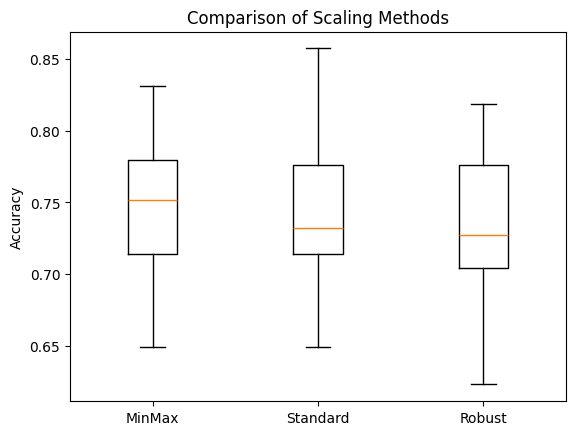

In [ ]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

pipeline_minmax = Pipeline([
    ('i', SimpleImputer(strategy='mean')),
    ('s', MinMaxScaler()),
    ('m', KNeighborsClassifier())
])

pipeline_standard = Pipeline([
    ('i', SimpleImputer(strategy='mean')),
    ('s', StandardScaler()),
    ('m', KNeighborsClassifier())
])

pipeline_robust = Pipeline([
    ('i', SimpleImputer(strategy='mean')),
    ('s', RobustScaler()),
    ('m', KNeighborsClassifier())
])

results = []
names = ['MinMax', 'Standard', 'Robust']
pipelines = [pipeline_minmax, pipeline_standard, pipeline_robust]

for name, pipeline in zip(names, pipelines):
    scores = cross_val_score(pipeline, X_pima, y_pima, scoring='accuracy', cv=cv)
    results.append(scores)
    print(f'{name} Scaling - Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')

pyplot.boxplot(results, labels=names)
pyplot.title('Comparison of Scaling Methods')
pyplot.ylabel('Accuracy')
pyplot.show()

### Knowledge Check (Problem 1)

**Question 1:** Why do we need `SimpleImputer` before `scaling` in this pipeline?

**Question 2:** How is the `KNeighborsClassifier` (KNN) model affected by data scaling?


**Q1:** SimpleImputer is needed before scaling because missing values (NaN) cannot be scaled directly. The imputer first fills in the missing values with the mean (or other strategy), allowing the scaler to then properly transform all values.

**Q2:** KNN model calculates distances between points. Without scaling, features with larger numeric ranges would dominate the distance calculations, leading to biased results. Scaling ensures all features contribute equally to the distance metrics, improving model performance.

## --- Problem 2: Apply Feature Selection (SelectKBest) ---

In [ ]:
print("\n--- Problem 2: Pima Diabetes Data (SelectKBest) ---")
# 1. Load and 2. Process Pima data
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
names = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class']
df_pima = pd.read_csv(url, header=None, names=names)
cols_with_zero_nan = ['plas', 'pres', 'skin', 'insu', 'mass']
df_pima[cols_with_zero_nan] = df_pima[cols_with_zero_nan].replace(0, np.nan)
X_pima = df_pima.drop('class', axis=1).values
y_pima = df_pima['class'].values # y is already 0/1
print("Pima dataset loaded and processed.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Create a single Pipeline that includes the following steps:
#    a. ('i', SimpleImputer(strategy='mean'))
#    b. ('s', SelectKBest(score_func=f_classif, k=4)) 
#    c. ('m', LogisticRegression(solver='liblinear'))
# 2. Define RepeatedStratifiedKFold.
# 3. Evaluate the pipeline using cross_val_score and print the mean accuracy.


--- Problem 2: Pima Diabetes Data (SelectKBest) ---
Pima dataset loaded and processed.


In [6]:
pipeline2 = Pipeline([
    ('i', SimpleImputer(strategy='mean')),
    ('s', SelectKBest(score_func=f_classif, k=4)),
    ('m', LogisticRegression(solver='liblinear'))
])

rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

scores = cross_val_score(pipeline2, X_pima, y_pima, scoring='accuracy', cv=rsf)
print(f'Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')

Mean Accuracy: 0.753 (+/- 0.041)


### Knowledge Check (Problem 2)

**Question 1:** What does `f_classif` (ANOVA F-test) used in `SelectKBest` measure?

**Question 2:** Why do we place `SimpleImputer` *before* `SelectKBest` in the pipeline?


**Question 1:** `f_classif` (ANOVA F-test) measures the relationship between each feature and the target by calculating the ratio of variance between the classes to the variance within the classes. Higher F-scores indicate stronger feature relevance for classification.

**Question 2:** `SimpleImputer` must be placed before `SelectKBest` because statistical tests like ANOVA F-test cannot process missing values (NaN). The imputer fills these gaps first, allowing `SelectKBest` to properly calculate feature importance scores.

## --- Problem 3: Tune the number of features 'k' using GridSearchCV ---

In [ ]:
print("\n--- Problem 3: Pima Diabetes Data (GridSearchCV) ---")
# 1. Load and process Pima data
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
names = ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class']
df_pima = pd.read_csv(url, header=None, names=names)
cols_with_zero_nan = ['plas', 'pres', 'skin', 'insu', 'mass']
df_pima[cols_with_zero_nan] = df_pima[cols_with_zero_nan].replace(0, np.nan)
X_pima = df_pima.drop('class', axis=1).values
y_pima = df_pima['class'].values # y is already 0/1
print("Pima dataset loaded and processed.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Create a Pipeline similar to Problem 2, but do *not* specify 'k' in SelectKBest.
#    (Just use: SelectKBest(score_func=f_classif)).
# 2. Define a 'param_grid' to search for 'k'. Hint: {'s__k': list(range(1, X_pima.shape[1] + 1))}
#    (Assuming your SelectKBest step is named 's').
# 3. Define RepeatedStratifiedKFold.
# 4. Create a GridSearchCV object wrapping the Pipeline, param_grid, and cv.
# 5. Run grid_search.fit() and print the best_params_ and best_score_.


--- Problem 3: Pima Diabetes Data (GridSearchCV) ---
Pima dataset loaded and processed.


In [8]:
pipeline3 = Pipeline([
    ('i', SimpleImputer(strategy='mean')),
    ('s', SelectKBest(score_func=f_classif)),
    ('m', LogisticRegression(solver='liblinear'))
])

param_grid = {'s__k': list(range(1, X_pima.shape[1] + 1))}
rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=pipeline3, param_grid=param_grid, scoring='accuracy', cv=rsf)
grid_search.fit(X_pima, y_pima)
print(f'Best Params: {grid_search.best_params_}')
print(f'Best Score: {grid_search.best_score_:.3f}')

Best Params: {'s__k': 7}
Best Score: 0.763


### Knowledge Check (Problem 3)

**Question 1:** What does `param_grid = {'s__k': ...}` mean? Why the `s__` (double underscore)?

**Question 2:** What is the benefit of wrapping the entire `Pipeline` in `GridSearchCV` instead of just running `GridSearchCV` on `SelectKBest` and then training the model?


**Q1:** The `s__k` syntax is used to specify parameters for a specific step in the Pipeline. Here, `s` refers to the `SelectKBest` step name, and `k` is the parameter being tuned. The double underscore `__` is the separator that Pipeline uses to identify which step and parameter you're targeting.

**Q2:** Wrapping the entire Pipeline in GridSearchCV ensures proper cross-validation and prevents data leakage. It applies feature selection on the training folds only, keeping the validation fold completely separate. If we ran GridSearchCV on SelectKBest alone, the feature selection would see all the data before model training, leading to data leakage and overly optimistic results.

### Dataset Introduction: Horse Colic

This is a classification dataset containing mixed-type data (both numerical and categorical features).

The goal is to predict whether a horse with colic will require surgery (column 23). Its main characteristic is the large number of missing values, marked with '?', making it an ideal case study for Imputation strategies.

## --- Problem 4: Compare statistical Imputation strategies ---

In [9]:
print("\n--- Problem 4: Horse Colic Data (Statistical Imputation) ---")
# 1. Load the Horse Colic dataset
X_hc, y_hc = load_horse_colic()
print("Horse Colic dataset loaded successfully.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define a list of strategies: ['mean', 'median', 'most_frequent', 'constant'].
# 2. Define RepeatedStratifiedKFold.
# 3. Loop through each strategy:
#    a. Create a Pipeline with (SimpleImputer(strategy=s), RandomForestClassifier()).
#    b. Evaluate and print the mean accuracy for that strategy.
# 4. (Optional) Plot a boxplot to compare the results.


--- Problem 4: Horse Colic Data (Statistical Imputation) ---
Horse Colic dataset loaded successfully.


Strategy: mean - Mean Accuracy: 0.858 (+/- 0.056)
Strategy: median - Mean Accuracy: 0.874 (+/- 0.058)
Strategy: most_frequent - Mean Accuracy: 0.869 (+/- 0.054)
Strategy: constant - Mean Accuracy: 0.881 (+/- 0.048)


/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z40000gn/T/ipykernel_19471/836739148.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results, labels=names)


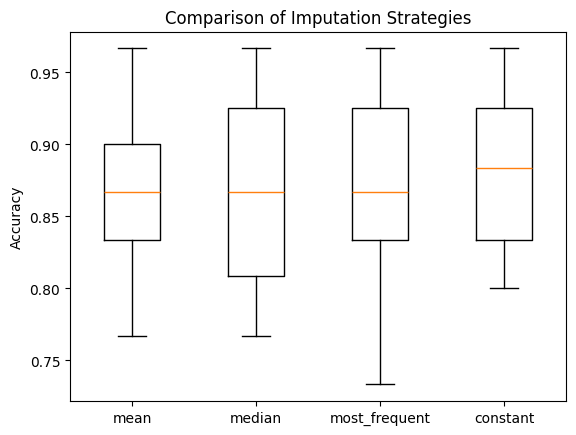

In [12]:
strategies = ['mean', 'median', 'most_frequent', 'constant']
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
results = []
names = []
for strategy in strategies:
    pipeline = Pipeline([
        ('i', SimpleImputer(strategy=strategy)),
        ('m', RandomForestClassifier())
    ])
    scores = cross_val_score(pipeline, X_hc, y_hc, scoring='accuracy', cv=cv)
    results.append(scores)
    names.append(strategy)
    print(f'Strategy: {strategy} - Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')
pyplot.boxplot(results, labels=names)
pyplot.title('Comparison of Imputation Strategies')
pyplot.ylabel('Accuracy')
pyplot.show()

### Knowledge Check (Problem 4)

**Question 1:** When should you use the 'median' strategy instead of 'mean' for `SimpleImputer`?

**Question 2:** Why is the 'most_frequent' strategy useful for the Horse Colic dataset?


**Q1:** 'median' strategy is preferred over 'mean' when:
- The data contains outliers that could skew the mean
- The feature distribution is not symmetric or is skewed

**Q2:** 'most_frequent' strategy is useful for the Horse Colic dataset because:
- It contains categorical features where mean/median imputation wouldn't make sense
- For binary or discrete variables, using the most common value is more appropriate
- It preserves the existing value distribution in the dataset

## --- Problem 5: Apply and tune 'k' for KNNImputer ---

In [13]:
print("\n--- Problem 5: Horse Colic Data (KNN Imputation) ---")
# 1. Load the Horse Colic dataset
X_hc, y_hc = load_horse_colic()
print("Horse Colic dataset loaded.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedStratifiedKFold.
# 2. Define a list of 'k' (neighbors) values to try: [1, 3, 5, 7, 9, 15, 21].
# 3. Loop through each 'k' value:
#    a. Create a Pipeline with (KNNImputer(n_neighbors=k), RandomForestClassifier()).
#    b. Evaluate and print the mean accuracy for that 'k'.
# 4. (Optional) Plot a boxplot to compare the results for each 'k'.


--- Problem 5: Horse Colic Data (KNN Imputation) ---
Horse Colic dataset loaded.


KNN Imputer k=1 - Mean Accuracy: 0.860 (+/- 0.037)
KNN Imputer k=3 - Mean Accuracy: 0.863 (+/- 0.033)
KNN Imputer k=5 - Mean Accuracy: 0.866 (+/- 0.042)
KNN Imputer k=7 - Mean Accuracy: 0.863 (+/- 0.035)
KNN Imputer k=9 - Mean Accuracy: 0.858 (+/- 0.035)
KNN Imputer k=15 - Mean Accuracy: 0.859 (+/- 0.033)
KNN Imputer k=21 - Mean Accuracy: 0.857 (+/- 0.046)


/var/folders/bg/hsvxykxj7yx0jz1nrhc3k6z40000gn/T/ipykernel_19471/2609179700.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  pyplot.boxplot(results, labels=names)


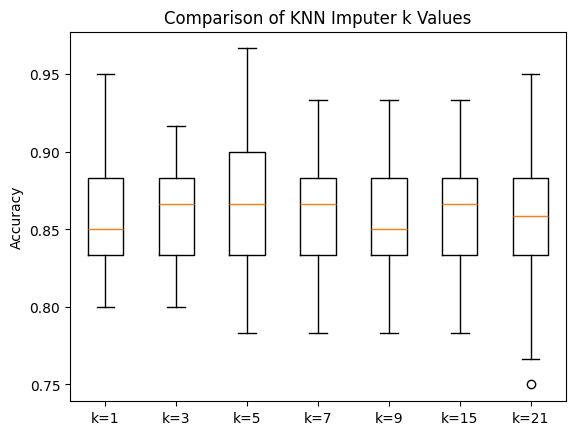

In [14]:
rsf = RepeatedStratifiedKFold()
k_values = [1, 3, 5, 7, 9, 15, 21]
results = []
names = []
for k in k_values:
    pipeline = Pipeline([
        ('i', KNNImputer(n_neighbors=k)),
        ('m', RandomForestClassifier())
    ])
    scores = cross_val_score(pipeline, X_hc, y_hc, scoring='accuracy', cv=rsf)
    results.append(scores)
    names.append(f'k={k}')
    print(f'KNN Imputer k={k} - Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')
pyplot.boxplot(results, labels=names)
pyplot.title('Comparison of KNN Imputer k Values')
pyplot.ylabel('Accuracy')
pyplot.show()

### Knowledge Check (Problem 5)

**Question 1:** How does `KNNImputer` work to fill in a missing value?

**Question 2:** Looking at the chart, why might `k=1` give a worse (or more varied) result than `k=5` or `k=7`?


**Q1:** `KNNImputer` works by:
- Finding the k-nearest neighbors of a sample with missing values
- Using those neighbors' values to estimate the missing value (typically by mean)
- Distance is calculated using the non-missing features

**Q2:** `k=1` performs worse because:
- It only uses a single nearest neighbor, making it highly sensitive to noise
- Larger k values (5 or 7) average multiple neighbors, providing more stable estimates
- Small k values can lead to overfitting, while moderate k values better balance bias and variance

## --- Problem 6: Apply IterativeImputer ---

In [15]:
print("\n--- Problem 6: Horse Colic Data (Iterative Imputation) ---")

# 1. Load data
X_hc, y_hc = load_horse_colic()
print("Horse Colic dataset loaded.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedStratifiedKFold.
# 2. Create a Pipeline with (IterativeImputer(max_iter=10, random_state=1), RandomForestClassifier()).
# 3. Evaluate and print the mean accuracy.


--- Problem 6: Horse Colic Data (Iterative Imputation) ---
Horse Colic dataset loaded.


In [16]:
rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
pipeline6 = Pipeline([
    ('i', IterativeImputer(max_iter=10, random_state=1)),
    ('m', RandomForestClassifier())
])
scores = cross_val_score(pipeline6, X_hc, y_hc, scoring='accuracy', cv=rsf)
print(f'Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')

Mean Accuracy: 0.874 (+/- 0.056)


### Knowledge Check (Problem 6)

**Question 1:** What is the fundamental difference between `IterativeImputer` and `SimpleImputer`/`KNNImputer`?


**Q1:** `IterativeImputer` uses a more sophisticated approach:
- It models each feature with missing values as a function of other features
- It iteratively estimates missing values by treating each feature as the target variable
- Unlike `SimpleImputer` (which uses a single statistic) or `KNNImputer` (which uses nearest neighbors), it learns feature relationships to make more informed predictions

### Dataset Introduction: Synthetic Regression

In this case study, we will not use real data but will create a "synthetic" dataset using `make_regression`.

We will intentionally create 1000 samples, 20 features, but only 10 are informative (`n_informative=10`). The goal is to see if `GridSearchCV` with `SelectKBest` (using `mutual_info_regression`) can correctly find these 10 important features.

## --- Problem 7: Tune Feature Selection for a Regression problem ---

In [17]:
print("\n--- Problem 7: Synthetic Regression (Feature Selection Tuning) ---")
# 1. Create a synthetic regression dataset
X_reg, y_reg = make_regression(n_samples=1000, n_features=20, n_informative=10, noise=0.1, random_state=1)

# --- EXERCISE REQUIREMENTS --- 
# 1. Create a Pipeline with:
#    a. ('s', SelectKBest(score_func=mutual_info_regression))
#    b. ('m', LinearRegression())
# 2. Define a 'param_grid' to find 's__k' (from 1 to 20).
# 3. Define RepeatedKFold (for regression).
# 4. Create a GridSearchCV, using scoring='neg_mean_absolute_error'.
# 5. Run grid_search.fit() and print the best 'k' and best MAE (absolute(best_score_)).


--- Problem 7: Synthetic Regression (Feature Selection Tuning) ---


In [18]:
pipeline7 = Pipeline([
    ('s', SelectKBest(score_func=mutual_info_regression)),
    ('m', LinearRegression())
])

param_grid = {'s__k': list(range(1, X_reg.shape[1] + 1))}
rkf = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=pipeline7, param_grid=param_grid, scoring='neg_mean_absolute_error', cv=rkf)
grid_search.fit(X_reg, y_reg)
best_k = grid_search.best_params_['s__k']
best_mae = absolute(grid_search.best_score_)
print(f'Best k: {best_k}')
print(f'Best MAE: {best_mae:.3f}')

Best k: 19
Best MAE: 0.083


### Knowledge Check (Problem 7)

**Question 1:** Why does this case study use `mutual_info_regression` and not `f_classif` (ANOVA) like in Problem 3?

**Question 2:** Why do we use `scoring='neg_mean_absolute_error'` (negative MAE) instead of 'accuracy'?


**Q1:** `mutual_info_regression` is used because:
- This is a regression problem, not classification
- It measures the statistical dependency between continuous variables
- Unlike ANOVA (f_classif) which is for classification tasks, mutual_info_regression works with continuous target variables

**Q2:** `neg_mean_absolute_error` is used because:
- Regression tasks measure prediction error, not accuracy
- sklearn scorers need to follow "higher is better" convention
- The negative sign converts MAE (where lower is better) to a format where higher scores are better
- Accuracy is only meaningful for classification tasks

### Dataset Introduction: Synthetic Classification

Similar to the previous case study, we create synthetic data using `make_classification`. 

We create 20 features, but only 10 are informative (`n_informative=10`) and 5 are redundant (`n_redundant=5`) (e.g., copies or linear combinations of informative features). The goal is to see if `RFE` (Recursive Feature Elimination) can effectively remove the redundant and irrelevant features.

## --- Problem 8: Apply Recursive Feature Elimination (RFE) ---

In [19]:
print("\n--- Problem 8: Synthetic Classification (RFE) ---")
# 1. Create a synthetic classification dataset
X_rfe, y_rfe = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, random_state=1)

# --- EXERCISE REQUIREMENTS --- 
# 1. Define an estimator: DecisionTreeClassifier(random_state=1).
# 2. Create a Pipeline with:
#    a. ('rfe', RFE(estimator=estimator, n_features_to_select=10)) (use the estimator you just defined)
#    b. ('m', DecisionTreeClassifier(random_state=1)) (as the final model)
# 3. Define RepeatedStratifiedKFold.
# 4. Evaluate the pipeline and print the mean accuracy.


--- Problem 8: Synthetic Classification (RFE) ---


In [20]:
estimator = DecisionTreeClassifier(random_state=1)
pipeline8 = Pipeline([
    ('rfe', RFE(estimator=estimator, n_features_to_select=10)),
    ('m', DecisionTreeClassifier(random_state=1))
])
rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(pipeline8, X_rfe, y_rfe, scoring='accuracy', cv=rsf)
print(f'Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')

Mean Accuracy: 0.844 (+/- 0.033)


### Knowledge Check (Problem 8)

**Question 1:** How does `RFE` (Recursive Feature Elimination) work?

**Question 2:** What is the difference between `RFE` (a Wrapper method) and `SelectKBest` (a Filter method)?


**Q1:** `RFE` works by:
- Starting with all features and recursively removing features
- Training a model (e.g., DecisionTreeClassifier) to rank feature importance
- Removing the least important features one by one until desired number remains
- The process is iterative, retraining the model after each elimination

**Q2:** Key differences:
- `RFE` (Wrapper): Uses a model to evaluate features iteratively, more computationally intensive but can capture feature interactions
- `SelectKBest` (Filter): Uses statistical tests (like f_classif) to evaluate each feature independently, faster but may miss feature relationships

### Dataset Introduction: Sonar, Mines vs. Rocks

This is a binary classification dataset. The goal is to predict if an underwater object is a Mine or a Rock based on 60 sonar signals.

All 60 features are numerical and range between 0 and 1. This data often does not follow a normal (Gaussian) distribution, making it a good candidate for Data Transforms like Power and Quantile.

## --- Problem 9: Compare Power Transforms (Yeo-Johnson vs. Box-Cox) ---

In [21]:
print("\n--- Problem 9: Sonar (Power Transform) ---")
# 1. Load the Sonar dataset
X_sonar, y_sonar = load_sonar()
print("Sonar dataset loaded successfully.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedStratifiedKFold.
# 2. Create Pipeline 1 (Yeo-Johnson):
#    a. ('s', StandardScaler())
#    b. ('p', PowerTransformer(method='yeo-johnson'))
#    c. ('m', KNeighborsClassifier())
# 3. Evaluate Pipeline 1 and print the result.
# 4. Create Pipeline 2 (Box-Cox) (Use the corrected version from the lecture):
#    a. ('s', StandardScaler())
#    b. ('scale_pos', MinMaxScaler(feature_range=(1, 2))) # Ensure > 0
#    c. ('p', PowerTransformer(method='box-cox'))
#    d. ('m', KNeighborsClassifier())
# 5. Evaluate Pipeline 2 and print the result.


--- Problem 9: Sonar (Power Transform) ---
Sonar dataset loaded successfully.


In [22]:
rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
pipeline91 = Pipeline([
    ('s', StandardScaler()),
    ('p', PowerTransformer(method='yeo-johnson')),
    ('m', KNeighborsClassifier())
])

scores1 = cross_val_score(pipeline91, X_sonar, y_sonar, scoring='accuracy', cv=rsf)
print(f'Yeo-Johnson - Mean Accuracy: {mean(scores1):.3f} (+/- {std(scores1):.3f})')
pipeline92 = Pipeline([
    ('s', StandardScaler()),
    ('scale_pos', MinMaxScaler(feature_range=(1, 2))), # Ensure > 0
    ('p', PowerTransformer(method='box-cox')),
    ('m', KNeighborsClassifier())
])
scores2 = cross_val_score(pipeline92, X_sonar, y_sonar, scoring='accuracy', cv=rsf)
print(f'Box-Cox - Mean Accuracy: {mean(scores2):.3f} (+/- {std(scores2):.3f})')

Yeo-Johnson - Mean Accuracy: 0.816 (+/- 0.077)
Box-Cox - Mean Accuracy: 0.811 (+/- 0.085)


### Knowledge Check (Problem 9)

**Question 1:** What is the goal of `PowerTransformer` (Yeo-Johnson, Box-Cox)?

**Question 2:** What is the main difference between 'Yeo-Johnson' and 'Box-Cox'?

**Question 3 (Advanced):** Why did the corrected `Box-Cox` pipeline need both `StandardScaler` and `MinMaxScaler(1, 2)`?


**Q1:** `PowerTransformer` aims to:
- Make data more Gaussian (normally distributed)
- Reduce skewness and stabilize variance
- Improve the performance of models that assume normality

**Q2:** Key differences:
- Box-Cox only works with strictly positive data (> 0)
- Yeo-Johnson can handle both positive and negative values
- Box-Cox is a simpler transformation but more restrictive

**Q3:** The pipeline needs both scalers because:
- `StandardScaler` first centers and scales the data
- `MinMaxScaler(1, 2)` ensures all values are > 1, which is required for Box-Cox
- Without this two-step scaling, Box-Cox would fail on values ≤ 0 or too close to zero

## --- Problem 10: Compare Quantile Transforms (Uniform vs. Normal) ---

In [ ]:
print("\n--- Problem 10: Sonar (Quantile Transform) ---")
# 1. Load data
X_sonar, y_sonar = load_sonar()
print("Sonar dataset loaded.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedStratifiedKFold.
# 2. Define a list: distributions = ['uniform', 'normal'].
# 3. Loop through each distribution:
#    a. Create a Pipeline with (QuantileTransformer(output_distribution=dist, ...), KNeighborsClassifier()).
#    Note: set n_quantiles=min(100, X_sonar.shape[0]-1) and random_state=1.
#    b. Evaluate and print the mean accuracy.
# 4. (Optional) Plot a boxplot comparing the 2 distributions.

### Knowledge Check (Problem 10)

**Question 1:** How does `QuantileTransformer(output_distribution='uniform')` transform the data?

**Question 2:** How does `QuantileTransformer` differ from `MinMaxScaler`, even though both can output data in the [0, 1] range?


## --- Problem 11: Compare Discretization Strategies ---

In [23]:
print("\n--- Problem 11: Sonar (Discretization) ---")
# 1. Load data
X_sonar, y_sonar = load_sonar()
print("Sonar dataset loaded.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedStratifiedKFold.
# 2. Define a list: strategies_disc = ['uniform', 'quantile', 'kmeans'].
# 3. Loop through each strategy:
#    a. Create a Pipeline with (KBinsDiscretizer(n_bins=5, encode='ordinal', strategy=strat_disc), KNeighborsClassifier()).
#    b. Evaluate and print the mean accuracy.
# 4. (Optional) Plot a boxplot comparing the 3 strategies.


--- Problem 11: Sonar (Discretization) ---
Sonar dataset loaded.


In [24]:
rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
pipeline11 = Pipeline([
    ('i', IterativeImputer(max_iter=10, random_state=1)),
    ('m', RandomForestClassifier())
])
scores = cross_val_score(pipeline11, X_hc, y_hc, scoring='accuracy', cv=rsf)
print(f'Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')

Mean Accuracy: 0.867 (+/- 0.047)


### Knowledge Check (Problem 11)

**Question 1:** What does `KBinsDiscretizer` (discretization) turn numerical data into?

**Question 2:** What is the difference between the 'uniform' and 'quantile' strategies?


**Q1:** `KBinsDiscretizer` turns continuous numerical data into discrete categorical data by:
- Dividing the continuous range into a fixed number of bins
- Assigning each value to a bin
- Converting continuous values into ordinal integers (when encode='ordinal')

**Q2:** Strategy differences:
- 'uniform': Creates equal-width bins by dividing the range into equal intervals
- 'quantile': Creates equal-frequency bins by ensuring roughly the same number of samples in each bin

## --- Problem 12: Apply PolynomialFeatures ---

In [25]:
print("\n--- Problem 12: Sonar (Polynomial Features) ---")
# 1. Load data
X_sonar, y_sonar = load_sonar()
print("Sonar dataset loaded.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedStratifiedKFold.
# 2. Create a Pipeline with:
#    a. ('p', PolynomialFeatures(degree=2, include_bias=False))
#    b. ('m', KNeighborsClassifier())
# 3. Evaluate and print the mean accuracy.


--- Problem 12: Sonar (Polynomial Features) ---
Sonar dataset loaded.


In [26]:
rsf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
pipeline12 = Pipeline([
    ('p', PolynomialFeatures(degree=2, include_bias=False)),
    ('m', KNeighborsClassifier())
])
scores = cross_val_score(pipeline12, X_sonar, y_sonar, scoring='accuracy', cv=rsf)
print(f'Mean Accuracy: {mean(scores):.3f} (+/- {std(scores):.3f})')

Mean Accuracy: 0.793 (+/- 0.085)


### Knowledge Check (Problem 12)

**Question 1:** What does `PolynomialFeatures(degree=2)` do? If the input has 2 features [a, b], what will the output be?

**Question 2:** Why is this helpful for models like `KNeighborsClassifier` or `LogisticRegression`?


**Q1:** `PolynomialFeatures(degree=2)` transforms features by:
- Creating combinations of features up to degree 2
- For input [a,b], output will be [1, a, b, a², ab, b²] (with include_bias=True)
- For input [a,b] without bias: [a, b, a², ab, b²]

**Q2:** It helps these models by:
- Adding non-linear feature interactions
- Allowing linear models to learn non-linear decision boundaries 
- Capturing feature relationships that simple distance metrics might miss

### Dataset Introduction: Abalone

This is a popular regression dataset. The goal is to predict the age of an abalone (target variable 'Rings') based on 8 physical features.

This dataset is a classic example of mixed-type data: it contains 7 numerical features (length, diameter, weight...) and 1 categorical feature (column 'Sex': 'M', 'F', 'I'). This makes it ideal for testing `ColumnTransformer`.

## --- Problem 13: Handle Mixed-Type Data with ColumnTransformer ---

In [27]:
print("\n--- Problem 13: Abalone (ColumnTransformer) ---")
# 1. Load data
X_abalone, y_abalone = load_abalone()
y_abalone = y_abalone.astype(int)
print("Abalone dataset loaded successfully.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Identify the column indices: categorical_features_idx = [0] and numerical_features_idx = list(range(1, X_abalone.shape[1])).
# 2. Create a ColumnTransformer:
#    a. Apply ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_idx)
#    b. Apply ('num', MinMaxScaler(), numerical_features_idx)
# 3. Create a Pipeline with:
#    a. ('trans', [Your ColumnTransformer])
#    b. ('m', SVR(gamma='scale'))
# 4. Define RepeatedKFold (for regression).
# 5. Evaluate the pipeline (scoring='neg_mean_absolute_error') and print the MAE.


--- Problem 13: Abalone (ColumnTransformer) ---
Abalone dataset loaded successfully.


In [28]:
categoryical_features_idx = [0]
numerical_features_idx = list(range(1, X_abalone.shape[1]))
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categoryical_features_idx),
    ('num', MinMaxScaler(), numerical_features_idx)
])
pipeline13 = Pipeline([
    ('trans', preprocessor),
    ('m', SVR(gamma='scale'))
])
rkf = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
scores = cross_val_score(pipeline13, X_abalone, y_abalone, scoring='neg_mean_absolute_error', cv=rkf)
print(f'Mean MAE: {absolute(mean(scores)):.3f} (+/- {std(scores):.3f})')

Mean MAE: 1.544 (+/- 0.086)


### Knowledge Check (Problem 13)

**Question 1:** What is the main purpose of `ColumnTransformer`?

**Question 2:** What does `OneHotEncoder` transform the 'Sex' column (with 3 values 'M', 'F', 'I') into?


**Q1:** `ColumnTransformer` allows:
- Different preprocessing steps for different types of features
- Parallel application of transformers to specific columns
- Proper handling of mixed-type data (numerical and categorical) in a single pipeline

**Q2:** `OneHotEncoder` transforms the 'Sex' column into:
- Three binary columns (one for each category)
- For example: 'M' becomes [1,0,0], 'F' becomes [0,1,0], 'I' becomes [0,0,1]
- This allows categorical data to be used with numerical algorithms

### Dataset Introduction: California Housing

This is a famous regression dataset from the 1990 California census. 

The goal is to predict the median house value for California districts. The features (e.g., median income, house age, num rooms...) are all numerical. The target variable (house value) has a skewed distribution, making it a good example for `TransformedTargetRegressor`.

## --- Problem 14: Apply a Transform to the Target Variable ---

In [29]:
print("\n--- Problem 14: Housing (Regression) - Target Transform ---")
# 1. Load data
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target
print("California Housing dataset loaded successfully.")

# --- EXERCISE REQUIREMENTS --- 
# 1. Define RepeatedKFold.
# 2. (For comparison) Create and evaluate a baseline Pipeline: (MinMaxScaler(), HuberRegressor()). Print its MAE.
# 3. (Main Task) Create a pipeline for the 'regressor': model_tt = Pipeline(steps=[('s', MinMaxScaler()), ('m', HuberRegressor())])
# 4. Create a 'transformer' for y: y_transformer = MinMaxScaler()
# 5. Create the final pipeline: pipeline_tt = TransformedTargetRegressor(regressor=model_tt, transformer=y_transformer)
# 6. Evaluate pipeline_tt (scoring='neg_mean_absolute_error') and print its MAE.
# 7. (Optional) Plot a boxplot to compare the baseline pipeline and the pipeline_tt.


--- Problem 14: Housing (Regression) - Target Transform ---
California Housing dataset loaded successfully.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lb

Baseline Pipeline - Mean MAE: 0.516 (+/- 0.011)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_huber.py:342: ConvergenceWarning: lb

Target Transform Pipeline - Mean MAE: 0.516 (+/- 0.011)


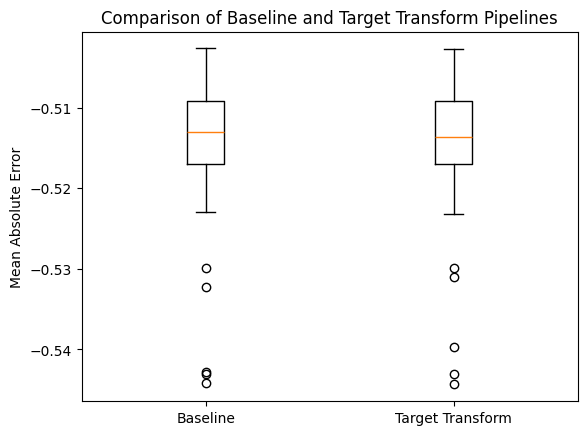

In [31]:
rk = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
# Baseline Pipeline
pipeline_baseline = Pipeline([
    ('s', MinMaxScaler()),
    ('m', HuberRegressor())
])
scores_baseline = cross_val_score(pipeline_baseline, X_housing, y_housing, scoring='neg_mean_absolute_error', cv=rk)
print(f'Baseline Pipeline - Mean MAE: {absolute(mean(scores_baseline)):.3f} (+/- {std(scores_baseline):.3f})')

# Pipeline with Target Transform
model_tt = Pipeline(steps=[
    ('s', MinMaxScaler()),
    ('m', HuberRegressor())
])
y_transformer = MinMaxScaler()
pipeline_tt = TransformedTargetRegressor(regressor=model_tt, transformer=y_transformer)
scores_tt = cross_val_score(pipeline_tt, X_housing, y_housing, scoring='neg_mean_absolute_error', cv=rk)
print(f'Target Transform Pipeline - Mean MAE: {absolute(mean(scores_tt)):.3f} (+/- {std(scores_tt):.3f})')

# boxplot
results = [scores_baseline, scores_tt]
names = ['Baseline', 'Target Transform']
pyplot.boxplot(results, labels=names)
pyplot.title('Comparison of Baseline and Target Transform Pipelines')
pyplot.ylabel('Mean Absolute Error')
pyplot.show()

### Knowledge Check (Problem 14)

**Question 1:** What does `TransformedTargetRegressor` do to the `y` variable (house price)?

**Question 2:** Why would we want to scale the `y` variable?


**Q1:** `TransformedTargetRegressor`:
- Applies a transformer (e.g., MinMaxScaler) to the target variable (y) before training
- Automatically inverts the transformation when making predictions
- Handles target variable transformations as part of the modeling pipeline

**Q2:** Scaling the `y` variable helps by:
- Making the target distribution more symmetric/normal
- Reducing the effect of outliers in house prices
- Stabilizing the variance of predictions
- Improving model convergence and numerical stability

In [30]:
print("\n--- All Exercises Completed ---")


--- All Exercises Completed ---
